# Occupation erasure via top-k selection

Erase **occupation** from off-the-shelf embeddings using **top-k greedy question selection**:
an LLM expands the concept into a pool of yes/no questions, JEV scores them, and `select_k` greedily
keeps the few that best reconstruct the pool. We then erase with just those and measure held-out
**occupation** accuracy before vs. after.

Runs offline from the bundled cache (`USE_CACHE=True`); set it `False` to call the APIs live.

In [1]:
import os, sys, json, hashlib, logging
from pathlib import Path
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')
for _n in ('httpx', 'httpcore', 'openai', 'openai._base_client'):
    logging.getLogger(_n).setLevel(logging.WARNING)       # silence OpenAI/OpenRouter request logs

def _root(s):
    for q in [Path(s).resolve(), *Path(s).resolve().parents]:
        if (q/'pyproject.toml').exists() and (q/'src'/'jevu').exists():
            return q
    return Path(s).resolve()
ROOT = _root(os.getcwd())
if str(ROOT/'src') not in sys.path: sys.path.insert(0, str(ROOT/'src'))
from jevu import ConceptScrubber

_envf = ROOT/'.env'
if _envf.exists():
    for _l in _envf.read_text().splitlines():
        _l = _l.strip()
        if _l and not _l.startswith('#') and '=' in _l:
            _k, _v = _l.split('=', 1); os.environ.setdefault(_k.strip(), _v.strip().strip('\'"'))

USE_CACHE = False        # offline from the bundled cache; set False to call APIs live
CACHE = (ROOT/'examples'/'.jev_debias_cache') if USE_CACHE else None
if CACHE: CACHE.mkdir(parents=True, exist_ok=True)
SEED, N, DENSE_MODEL = 2026, 900, 'text-embedding-3-small'
DATASET, CONFIG, SPLIT = 'LabHC/bias_in_bios', 'default', 'test'
HF_ROWS = 'https://datasets-server.huggingface.co/rows'
def dg(x): return hashlib.sha256(json.dumps(x, sort_keys=True, ensure_ascii=False).encode()).hexdigest()
def sj(p, x): p.write_text(json.dumps(x, ensure_ascii=False))
print('caching:', bool(CACHE))

caching: False


## 1. Data: real bios + off-the-shelf embeddings

In [2]:
def hf_page(off, length=100):
    p = (CACHE/f'bios_{SPLIT}_{off}_{length}.json') if CACHE else None
    if p and p.exists(): return json.loads(p.read_text())
    import httpx
    r = httpx.get(HF_ROWS, params={'dataset': DATASET, 'config': CONFIG, 'split': SPLIT, 'offset': int(off), 'length': int(length)}, timeout=60); r.raise_for_status()
    d = r.json();
    if p: sj(p, d)
    return d

def load_bios(n, seed):
    p = (CACHE/f'bios_sample_{n}_{seed}.json') if CACHE else None
    if p and p.exists(): return json.loads(p.read_text())['rows']
    total = hf_page(0, 1)['num_rows_total']; rng = np.random.default_rng(seed)
    rows = []
    for off in rng.permutation(np.arange(0, total, 100)):
        for it in hf_page(int(off), 100)['rows']:
            r = it['row']; t = str(r['hard_text'] or '').strip()
            if t: rows.append({'text': t[:700], 'prof': int(r['profession']), 'gender': int(r['gender'])})
        if len(rows) >= n: break
    rng.shuffle(rows); rows = rows[:n]
    if p: sj(p, {'rows': rows})
    return rows

def embed_dense(texts):
    p = (CACHE/f'dense_{dg({"m": DENSE_MODEL, "t": texts})}.json') if CACHE else None
    if p and p.exists(): return np.asarray(json.loads(p.read_text()), dtype=float)
    from openai import OpenAI
    cl = OpenAI(timeout=90); v = []
    for s in range(0, len(texts), 200):
        v.extend(x.embedding for x in cl.embeddings.create(model=DENSE_MODEL, input=texts[s:s+200]).data)
    v = np.asarray(v, dtype=float)
    if p: sj(p, v.tolist())
    return v

rows = load_bios(N, SEED)
texts = [r['text'] for r in rows]
prof = np.array([r['prof'] for r in rows]); gender = np.array([r['gender'] for r in rows])
X = normalize(embed_dense(texts))
tr, te = train_test_split(np.arange(N), test_size=0.3, random_state=SEED, stratify=gender)
print(len(texts), 'bios |', len(np.unique(prof)), 'occupations | embeddings', X.shape)

INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


900 bios | 28 occupations | embeddings (900, 1536)


## 2. The data split (occupations × gender)

The corpus is highly imbalanced across the 28 occupations, and several are gender-skewed — which is exactly what makes a 28-way probe need many rows and what gender-biased retrieval keys on.

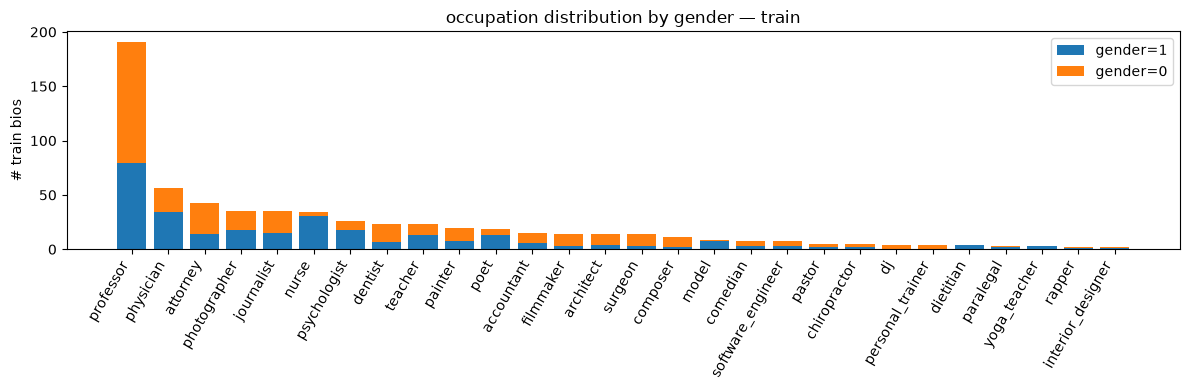

In [3]:
import matplotlib.pyplot as plt
PROFESSIONS = ['accountant','architect','attorney','chiropractor','comedian','composer','dentist','dietitian','dj','filmmaker','interior_designer','journalist','model','nurse','painter','paralegal','pastor','personal_trainer','photographer','physician','poet','professor','psychologist','rapper','software_engineer','surgeon','teacher','yoga_teacher']
vals = np.unique(prof[tr])
fem = np.array([np.sum((prof[tr] == v) & (gender[tr] == 1)) for v in vals])
mal = np.array([np.sum((prof[tr] == v) & (gender[tr] == 0)) for v in vals])
order = np.argsort(-(fem + mal))
plt.figure(figsize=(12, 4))
plt.bar(range(len(vals)), fem[order], label='gender=1')
plt.bar(range(len(vals)), mal[order], bottom=fem[order], label='gender=0')
plt.xticks(range(len(vals)), [PROFESSIONS[v] for v in vals[order]], rotation=60, ha='right')
plt.ylabel('# train bios'); plt.legend(); plt.title('occupation distribution by gender — train')
plt.tight_layout(); plt.show()

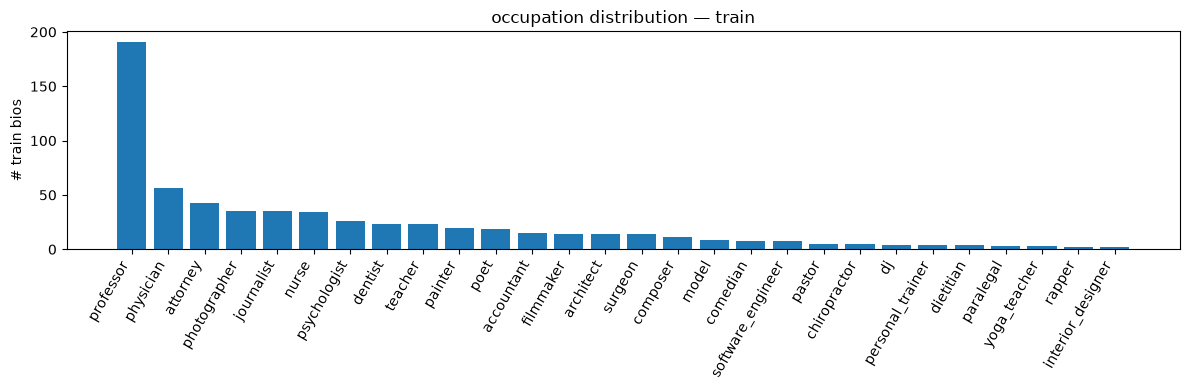

In [4]:
PROFESSIONS = [
    'accountant', 'architect', 'attorney', 'chiropractor', 'comedian', 'composer',
    'dentist', 'dietitian', 'dj', 'filmmaker', 'interior_designer', 'journalist',
    'model', 'nurse', 'painter', 'paralegal', 'pastor', 'personal_trainer',
    'photographer', 'physician', 'poet', 'professor', 'psychologist', 'rapper',
    'software_engineer', 'surgeon', 'teacher', 'yoga_teacher',
]   # index == the `prof` integer

names = [PROFESSIONS[i] for i in prof]          # per-bio occupation name
PROFESSIONS[prof[0]]                             # one bio's occupation

import matplotlib.pyplot as plt, numpy as np
vals, counts = np.unique(prof[tr], return_counts=True)
order = np.argsort(-counts)
plt.figure(figsize=(12, 4))
plt.bar(range(len(vals)), counts[order])
plt.xticks(range(len(vals)), [PROFESSIONS[v] for v in vals[order]], rotation=60, ha='right')
plt.ylabel('# train bios'); plt.title('occupation distribution — train')
plt.tight_layout(); plt.show()

## 3. Erase occupation with top-k selected questions

Pool of **15** questions; sweep `select_k` to see how few questions you need. The greedy picks are logged (`INFO jevu.scrubber: greedy select …`) and stored in `selected_questions_`.

Selection runs on a **250-row sample** (`select_sample=250`): the pool is scored only on the sample, then just the kept questions are scored on the full train split.

In [5]:
CONCEPT = 'the specific profession or occupation the person has'
def acc(A, B):
    return accuracy_score(prof[te], LogisticRegression(max_iter=3000).fit(A, prof[tr]).predict(B))

print('raw occupation acc:', round(acc(X[tr], X[te]), 3))
print('\n--- sample 250 -> score pool -> select k -> score k on full train -> fit -> eval on held-out test ---')
for k in [1, 3, 6]:
    scr = ConceptScrubber(method='leace', expand=True, concept=CONCEPT, n_questions=15,
                          select_k=k, select_sample=250,
                          cache_dir=str(CACHE) if CACHE else None, max_workers=24)
    scr.fit(embeddings=X[tr], texts=[texts[i] for i in tr])   # select on 250, fit eraser on full train
    Xd = scr.transform(X)
    print(f'  k={k:<2} occupation acc {acc(Xd[tr], Xd[te]):.3f}')
    for q in scr.selected_questions_: print('        -', q)

raw occupation acc: 0.648

--- sample 250 -> score pool -> select k -> score k on full train -> fit -> eval on held-out test ---


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO jevu.concepts: expanded concept 'the specific profession or occupation the person has' into 15 questions: ['Does the text describe someone in a teaching profession?', 'Does the text describe someone in the field of law?', 'Does the text mention a person who works in the arts or artistic fields?', 'Does the text highlight someone working as a medical professional?', 'Does the text refer to someone involved in journalism or writing?', 'Does the text indicate a person who has worked in scientific research or academia?', 'Does the text describe someone involved in community service or social work?', 'Does the text describe an individual working in technology or engineering?', 'Does the text mention a person involved in physical training or athletics?', 'Does the text describe someone in a health or wellness-related role?', 'Does the text reference someone participating in photography or visual arts?', 'Does the text mention someone working in the field of sociology or social sciences?

INFO jevu.scrubber: selecting 1/15 questions on a 250-row sample


INFO jevu.concepts: scoring 250 texts x 15 questions = 3750 cells (0 cached, 3750 to fetch)


...

INFO jevu.scrubber: kept 6/15 questions: ['Does the text refer to an educator or academic?', 'Does the text refer to a healthcare professional?', 'Does the text refer to an artist or performer?', 'Does the text refer to a journalist or writer?', 'Does the text refer to a researcher or scientist?', 'Does the text refer to someone involved in photography or visual arts?']


INFO jevu.concepts: scoring 630 texts x 6 questions = 3780 cells (0 cached, 3780 to fetch)


JEV x6: the specific profession or occ:   0%|          | 0/3780 [00:00<?, ?it/s]

INFO jevu.erasers: LEACE erased concept (d=1536, k=6)


  k=6  occupation acc 0.333
        - Does the text refer to an educator or academic?
        - Does the text refer to a healthcare professional?
        - Does the text refer to an artist or performer?
        - Does the text refer to a journalist or writer?
        - Does the text refer to a researcher or scientist?
        - Does the text refer to someone involved in photography or visual arts?


## 4. PCA: embeddings before vs. after erasure

Same 2-D PCA axes for both panels (fit on the originals). Colored by the top occupations: the clusters that separate professions **before** collapse/merge **after** erasing occupation.

INFO httpx2: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO jevu.concepts: expanded concept 'the specific profession or occupation the person has' into 15 questions: ['Does the text refer to a healthcare professional?', 'Does the text refer to someone working in education?', 'Does the text refer to an author or writer?', 'Does the text refer to a legal professional?', 'Does the text refer to an artist or performer?', 'Does the text refer to a researcher or academic?', 'Does the text refer to someone in journalism or media?', 'Does the text refer to someone in community service or social work?', 'Does the text refer to a scientist or engineer?', 'Does the text refer to someone involved in photography?', 'Does the text refer to someone in technology or computing?', 'Does the text refer to a dentist?', 'Does the text refer to a healthcare provider specializing in mental health?', 'Does the text refer to a linguist or language educator?', 'Does the text refer to someone involved in art or illustration?']


INFO jevu.scrubber: selecting 3/15 questions on a 250-row sample


INFO jevu.concepts: scoring 250 texts x 15 questions = 3750 cells (0 cached, 3750 to fetch)


JEV x15: the specific profession or occ:   0%|          | 0/3750 [00:00<?, ?it/s]

...

INFO jevu.scrubber: greedy select 3/3: 'Does the text refer to someone involved in art or illustration?' (reconstruction residual 11.865)


INFO jevu.scrubber: kept 3/15 questions: ['Does the text refer to a researcher or academic?', 'Does the text refer to a healthcare professional?', 'Does the text refer to someone involved in art or illustration?']


INFO jevu.concepts: scoring 630 texts x 3 questions = 1890 cells (0 cached, 1890 to fetch)


JEV x3: the specific profession or occ:   0%|          | 0/1890 [00:00<?, ?it/s]

INFO jevu.erasers: LEACE erased concept (d=1536, k=3)


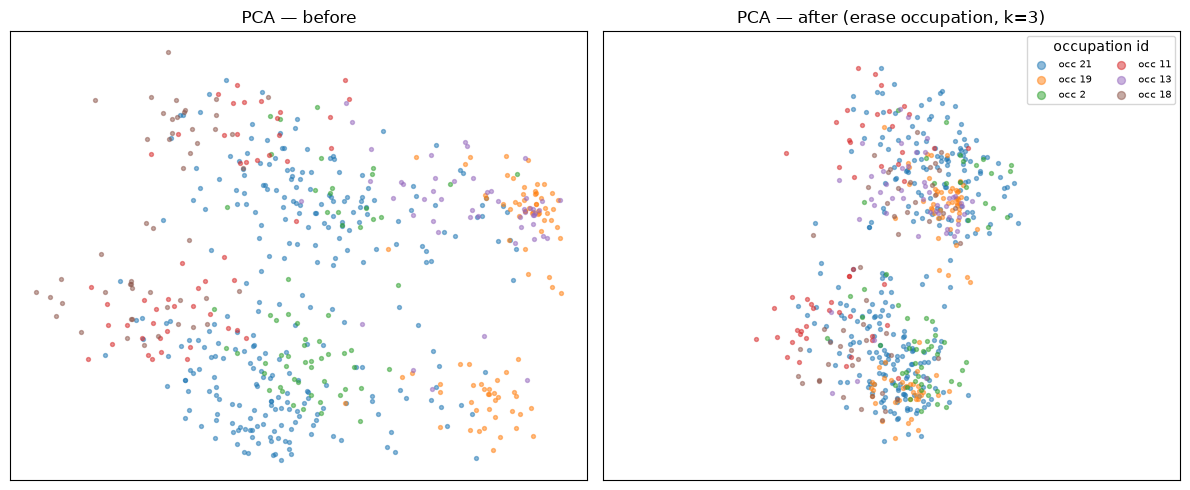

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
scr_v = ConceptScrubber(method='leace', expand=True, concept=CONCEPT, n_questions=15,
                        select_k=3, select_sample=250, cache_dir=str(CACHE) if CACHE else None, max_workers=24)
scr_v.fit(embeddings=X[tr], texts=[texts[i] for i in tr]); Xd = scr_v.transform(X)
pca = PCA(n_components=2, random_state=SEED).fit(X)
PB, PA = pca.transform(X), pca.transform(Xd)
vals, counts = np.unique(prof, return_counts=True); top = vals[np.argsort(-counts)[:6]]
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for axi, (P, ttl) in zip(ax, [(PB, 'before'), (PA, 'after (erase occupation, k=3)')]):
    for t in top:
        m = prof == t; axi.scatter(P[m, 0], P[m, 1], s=8, alpha=0.5, label=f'occ {t}')
    axi.set_title(f'PCA — {ttl}'); axi.set_xticks([]); axi.set_yticks([])
ax[1].legend(fontsize=7, ncol=2, markerscale=2, title='occupation id')
plt.tight_layout(); plt.show()

## 5. Why it works: which professions the selected questions cover

Each selected question fires (high JEV score) on a cluster of occupations. The heatmap shows the mean score of each of the 3 selected questions per occupation; the bar below is each occupation's **best** coverage. Occupations **covered** by some selected question (green) lose their direction and get erased; **uncovered** ones (red) survive — which is why a small k only partially drops occupation accuracy.

INFO jevu.concepts: scoring 630 texts x 3 questions = 1890 cells (0 cached, 1890 to fetch)


JEV x3: the specific profession or occ:   0%|          | 0/1890 [00:00<?, ?it/s]

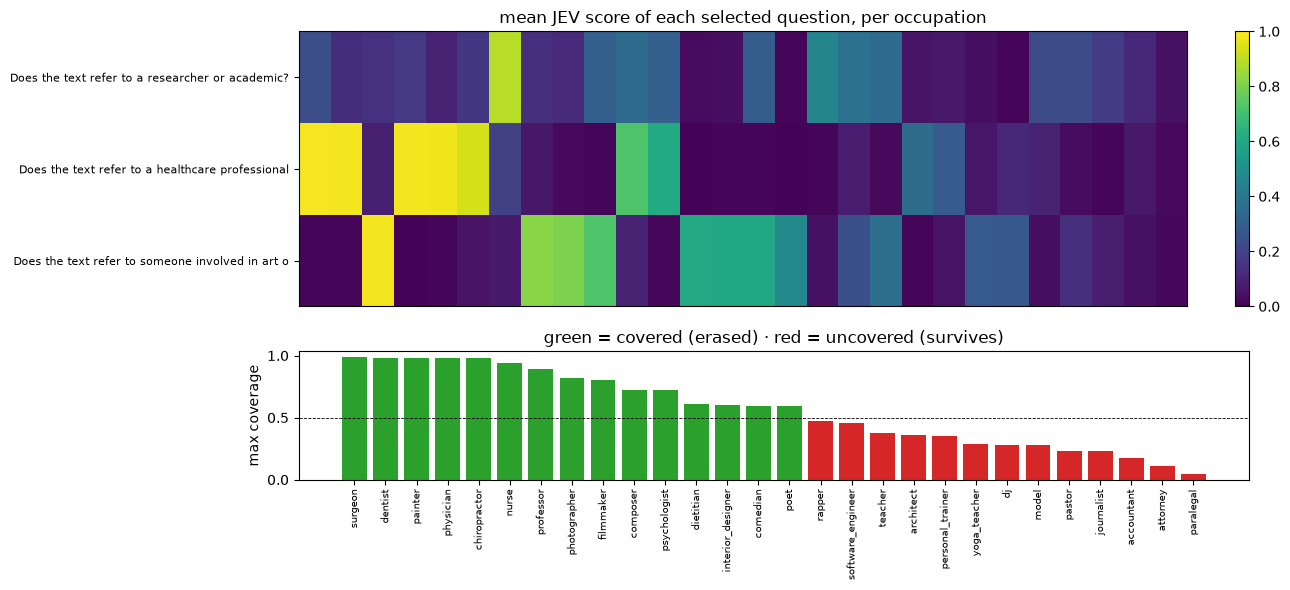

In [7]:
sel = scr_v.selected_questions_
Zsel = scr_v._labeler_().score_questions(sel, [texts[i] for i in tr])   # (630, k), cached
ptr = prof[tr]; profs = np.unique(ptr)
cov = np.array([[Zsel[ptr == p, j].mean() for p in profs] for j in range(len(sel))])  # (k, n_prof)
col = np.argsort(-cov.max(axis=0))                                    # occupations by best coverage
fig, ax = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={'height_ratios': [len(sel), 1.4]})
im = ax[0].imshow(cov[:, col], aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax[0].set_yticks(range(len(sel))); ax[0].set_yticklabels([q[:48] for q in sel], fontsize=8)
ax[0].set_xticks([]); ax[0].set_title('mean JEV score of each selected question, per occupation')
fig.colorbar(im, ax=ax[0], fraction=0.015)
best = cov.max(axis=0)[col]
ax[1].bar(range(len(profs)), best, color=['tab:green' if b >= 0.5 else 'tab:red' for b in best])
ax[1].axhline(0.5, color='k', lw=0.6, ls='--')
ax[1].set_xticks(range(len(profs))); ax[1].set_xticklabels([PROFESSIONS[p] for p in profs[col]], rotation=90, fontsize=7)
ax[1].set_ylabel('max coverage'); ax[1].set_title('green = covered (erased) · red = uncovered (survives)')
plt.tight_layout(); plt.show()

## 6. Reading it

More selected questions → more of the concept removed → lower occupation accuracy. A binary concept needs ~1 question; a many-valued identity needs a small covering set. The chosen questions are reusable: deploy just those few to scrub new embeddings cheaply.